<h1>
  Análise de Preços
</h1>

## Bibliotecas

In [7]:
import pandas as pd
import pyspark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

## Funções

In [8]:
from os import truncate
def carregar_df_csv(caminho:str):
    df = pd.read_csv(caminho)
    return df

def transformar_spark(sessao_spark,df:pd.DataFrame):
 return sessao_spark.createDataFrame(df)

def criar_view(df, nome_view):
 return df.createOrReplaceTempView(nome_view)

def executar_sql(sessao_spark, query):
  return sessao_spark.sql(query)

def ver_df(df):
  return df.show(truncate=False)

## ETL

In [9]:
sessao_spark = SparkSession.builder.appName("Análise de NPS").getOrCreate()

In [10]:
caminho_clientes = "/content/olist_customers_dataset.csv"
caminho_itens = "/content/olist_order_items_dataset.csv"
caminho_pedidos = "/content/olist_orders_dataset.csv"
caminho_avaliacoes = "/content/olist_order_reviews_dataset.csv"
caminho_produtos = "/content/olist_products_dataset.csv"
caminho_vendedores = "/content/olist_sellers_dataset.csv"

## Clientes

In [11]:
df_clientes = carregar_df_csv(caminho_clientes)

df_clientes = transformar_spark(sessao_spark,df_clientes)

criar_view(df_clientes,"dim_clientes")

## Itens

In [12]:
df_itens = carregar_df_csv(caminho_itens)

df_itens = transformar_spark(sessao_spark,df_itens)

criar_view(df_itens,"fat_itens")

## Pedidos

In [13]:
df_pedidos = carregar_df_csv(caminho_pedidos)

df_pedidos = transformar_spark(sessao_spark,df_pedidos)

criar_view(df_pedidos,"fat_pedidos")

## Avaliações

In [14]:
df_avaliacoes = carregar_df_csv(caminho_avaliacoes)

df_avaliacoes = transformar_spark(sessao_spark,df_avaliacoes)

criar_view(df_avaliacoes,"dim_avaliacoes")

## Produtos

In [15]:
df_produtos = carregar_df_csv(caminho_produtos)

df_produtos = transformar_spark(sessao_spark,df_produtos)

criar_view(df_produtos,"dim_produtos")

## Vendedores

In [16]:
df_vendedores = carregar_df_csv(caminho_vendedores)

df_vendedores = transformar_spark(sessao_spark,df_vendedores)

criar_view(df_vendedores,"dim_vendedores")

## Unindo a nota ao pedido

In [17]:
consulta_avaliacoes = \
"""
SELECT
p.order_id AS id_pedido,
c.customer_unique_id AS id_cliente,
prod.product_category_name AS categoria_produto,
p.order_status AS status,
av.review_score AS nota,
c.customer_city AS cidade_cliente,
c.customer_state AS estado_cliente,
ROUND(i.price,2) AS valor_produto,
ROUND(i.freight_value,2) AS valor_frete,
ROUND(i.price + i.freight_value,2) AS valor_total,
av.review_creation_date AS data_avaliacao,
p.order_delivered_customer_date AS data_entrega_cliente
FROM fat_pedidos p
INNER JOIN dim_avaliacoes av
ON av.order_id = p.order_id
INNER JOIN dim_clientes c
ON  c.customer_id = p.customer_id
INNER JOIN fat_itens i
ON i.order_id = p.order_id
INNER JOIN dim_produtos prod
ON prod.product_id = i.product_id
WHERE p.order_status = 'delivered'


"""


df_avaliacoes = executar_sql(sessao_spark, consulta_avaliacoes)

In [18]:
ver_df(df_avaliacoes)

+--------------------------------+--------------------------------+---------------------------+---------+----+-----------------------+--------------+-------------+-----------+-----------+-------------------+--------------------+
|id_pedido                       |id_cliente                      |categoria_produto          |status   |nota|cidade_cliente         |estado_cliente|valor_produto|valor_frete|valor_total|data_avaliacao     |data_entrega_cliente|
+--------------------------------+--------------------------------+---------------------------+---------+----+-----------------------+--------------+-------------+-----------+-----------+-------------------+--------------------+
|00018f77f2f0320c557190d7a144bdd3|eb28e67c4c0b83846050ddfb8a35d051|pet_shop                   |delivered|4   |santa fe do sul        |SP            |239.9        |19.93      |259.83     |2017-05-13 00:00:00|2017-05-12 16:04:24 |
|000229ec398224ef6ca0657da4fc703e|3818d81c6709e39d06b2738a8d3a2474|moveis_decoracao 

In [19]:
criar_view(df_avaliacoes,"fat_pedidos_avaliados")

In [20]:
consulta_aval_somadas = \
"""
SELECT SUM(valor_total) AS total_gasto, estado_cliente
FROM fat_pedidos_avaliados
GROUP BY valor_total, estado_cliente
"""

df_total_gasto = executar_sql(sessao_spark, consulta_aval_somadas)

In [21]:
ver_df(df_total_gasto)

+-----------+--------------+
|total_gasto|estado_cliente|
+-----------+--------------+
|403.16     |RS            |
|101.44     |MT            |
|105.84     |PI            |
|254.56     |SP            |
|239.75     |SP            |
|169.37     |SP            |
|455.2      |MG            |
|125.0      |RJ            |
|338.88     |ES            |
|1367.43    |MG            |
|73.07      |RJ            |
|690.06     |SP            |
|298.83     |RJ            |
|72.03      |MG            |
|158.98     |RS            |
|87.76      |PA            |
|271.84     |MG            |
|477.88     |SP            |
|329.14     |MG            |
|133.3      |ES            |
+-----------+--------------+
only showing top 20 rows


## Análise exploratória

In [22]:
# Quantidade de registros
df_avaliacoes.count()

110013

In [23]:
#Quantidade de registros nulos por coluna:

df_avaliacoes.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_avaliacoes.columns
]).show()

+---------+----------+-----------------+------+----+--------------+--------------+-------------+-----------+-----------+--------------+--------------------+
|id_pedido|id_cliente|categoria_produto|status|nota|cidade_cliente|estado_cliente|valor_produto|valor_frete|valor_total|data_avaliacao|data_entrega_cliente|
+---------+----------+-----------------+------+----+--------------+--------------+-------------+-----------+-----------+--------------+--------------------+
|        0|         0|                0|     0|   0|             0|             0|            0|          0|          0|             0|                   0|
+---------+----------+-----------------+------+----+--------------+--------------+-------------+-----------+-----------+--------------+--------------------+



## (1) A nota do pedido influencia diretamente o valor?



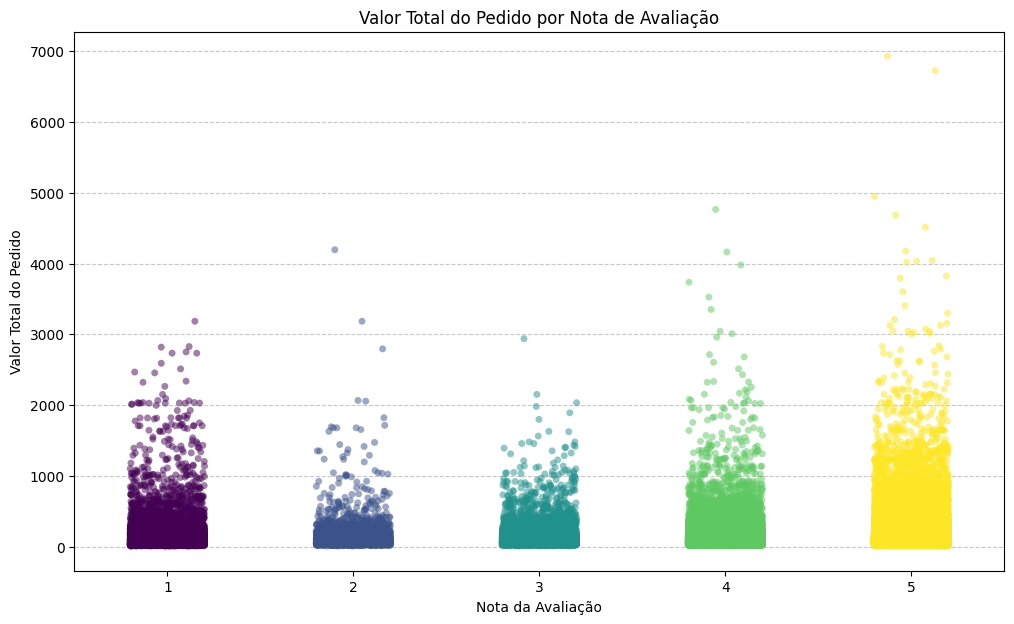

In [24]:
#Gráfico de Faixa
df_grafico_faixa = df_avaliacoes.select('nota', 'valor_total').toPandas()

plt.figure(figsize=(12, 7))
sns.stripplot(data=df_grafico_faixa, x='nota', y='valor_total', jitter=0.2, alpha=0.5, palette='viridis', hue='nota', legend=False)
plt.title('Valor Total do Pedido por Nota de Avaliação')
plt.xlabel('Nota da Avaliação')
plt.ylabel('Valor Total do Pedido')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

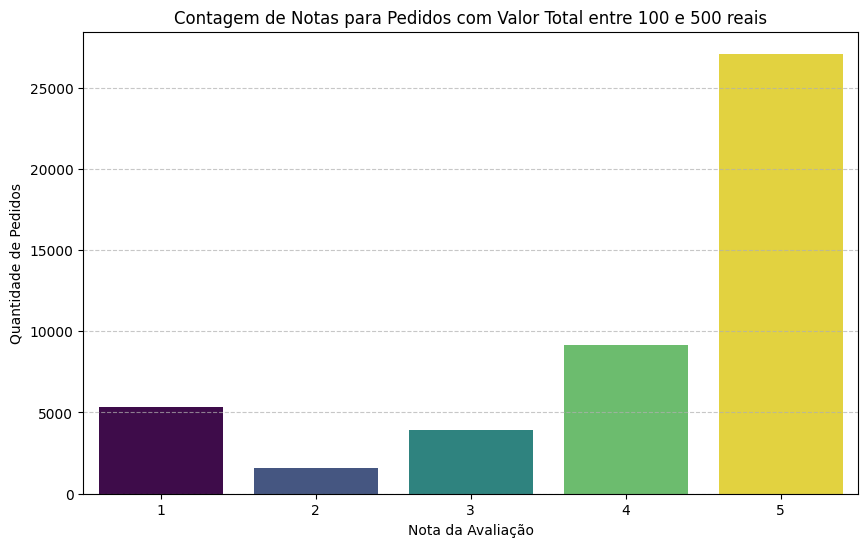

In [25]:
#Quantidade de pedidos por faixa de preço - 100 a 1000

df_faixa_preco = df_avaliacoes.filter((F.col('valor_total') >= 100) & (F.col('valor_total') <= 500))

df_contagem_notas_faixa = df_faixa_preco.groupBy('nota').count().orderBy('nota').toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_contagem_notas_faixa, x='nota', y='count', palette='viridis', hue='nota', legend=False)
plt.title('Contagem de Notas para Pedidos com Valor Total entre 100 e 500 reais')
plt.xlabel('Nota da Avaliação')
plt.ylabel('Quantidade de Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

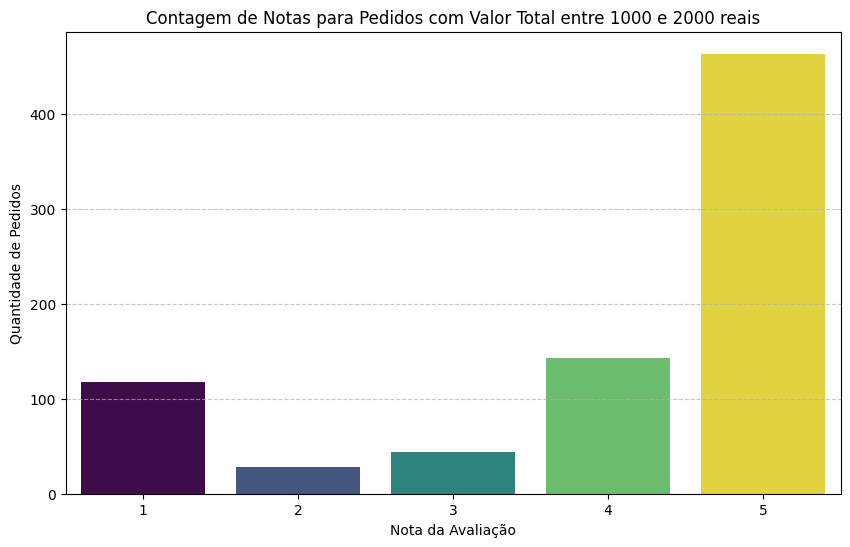

In [26]:
#Quantidade de pedidos por faixa de preço - 1000 a 2000

df_faixa_preco = df_avaliacoes.filter((F.col('valor_total') >= 1000) & (F.col('valor_total') <= 2000))

df_contagem_notas_faixa = df_faixa_preco.groupBy('nota').count().orderBy('nota').toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_contagem_notas_faixa, x='nota', y='count', palette='viridis', hue='nota', legend=False)
plt.title('Contagem de Notas para Pedidos com Valor Total entre 1000 e 2000 reais')
plt.xlabel('Nota da Avaliação')
plt.ylabel('Quantidade de Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

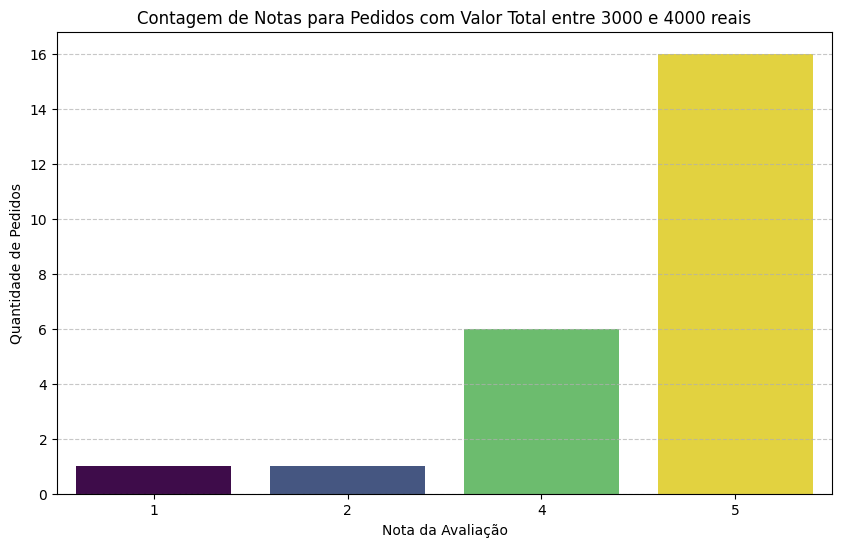

In [27]:
#Quantidade de pedidos por faixa de preço - 3000 a 4000

df_faixa_preco = df_avaliacoes.filter((F.col('valor_total') >= 3000) & (F.col('valor_total') <= 4000))

df_contagem_notas_faixa = df_faixa_preco.groupBy('nota').count().orderBy('nota').toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_contagem_notas_faixa, x='nota', y='count', palette='viridis', hue='nota', legend=False)
plt.title('Contagem de Notas para Pedidos com Valor Total entre 3000 e 4000 reais')
plt.xlabel('Nota da Avaliação')
plt.ylabel('Quantidade de Pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

## (2) Quais estados possuem as melhores avaliações?

In [32]:
consulta_melhores_estados_avaliacao = """
SELECT
    estado_cliente,
    ROUND(AVG(nota), 2) AS media_nota_avaliacao
FROM fat_pedidos_avaliados
GROUP BY estado_cliente
ORDER BY media_nota_avaliacao DESC
LIMIT 10
"""

df_melhores_estados = executar_sql(sessao_spark, consulta_melhores_estados_avaliacao)

df_melhores_estados_pd = df_melhores_estados.toPandas()

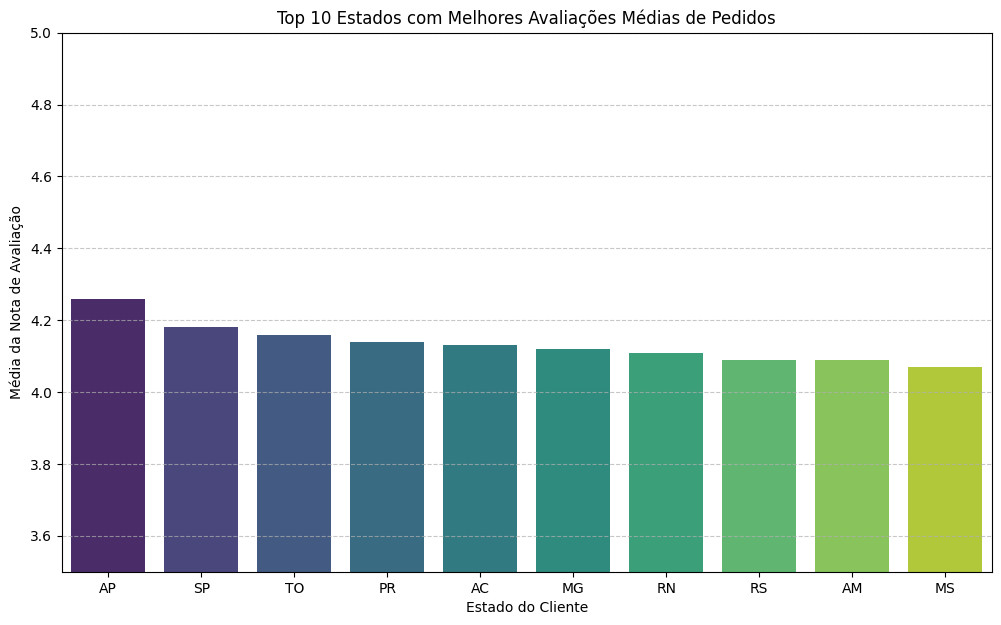

In [34]:
plt.figure(figsize=(12, 7))
sns.barplot(x='estado_cliente', y='media_nota_avaliacao', data=df_melhores_estados_pd, palette='viridis', hue='estado_cliente', legend=False)
plt.title('Top 10 Estados com Melhores Avaliações Médias de Pedidos')
plt.xlabel('Estado do Cliente')
plt.ylabel('Média da Nota de Avaliação')
plt.ylim(3.5, 5.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()